# Task 6: Lane Detection using Hough Line Transform
images and video are from udacity lane lines project (road camera images)

steps: gray -> blur -> canny -> region of interest -> HoughLinesP -> separate left/right by slope -> average and draw

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

files = ["images/solidWhiteCurve.jpg", "images/solidWhiteRight.jpg", "images/solidYellowLeft.jpg"]

### step by step on one image

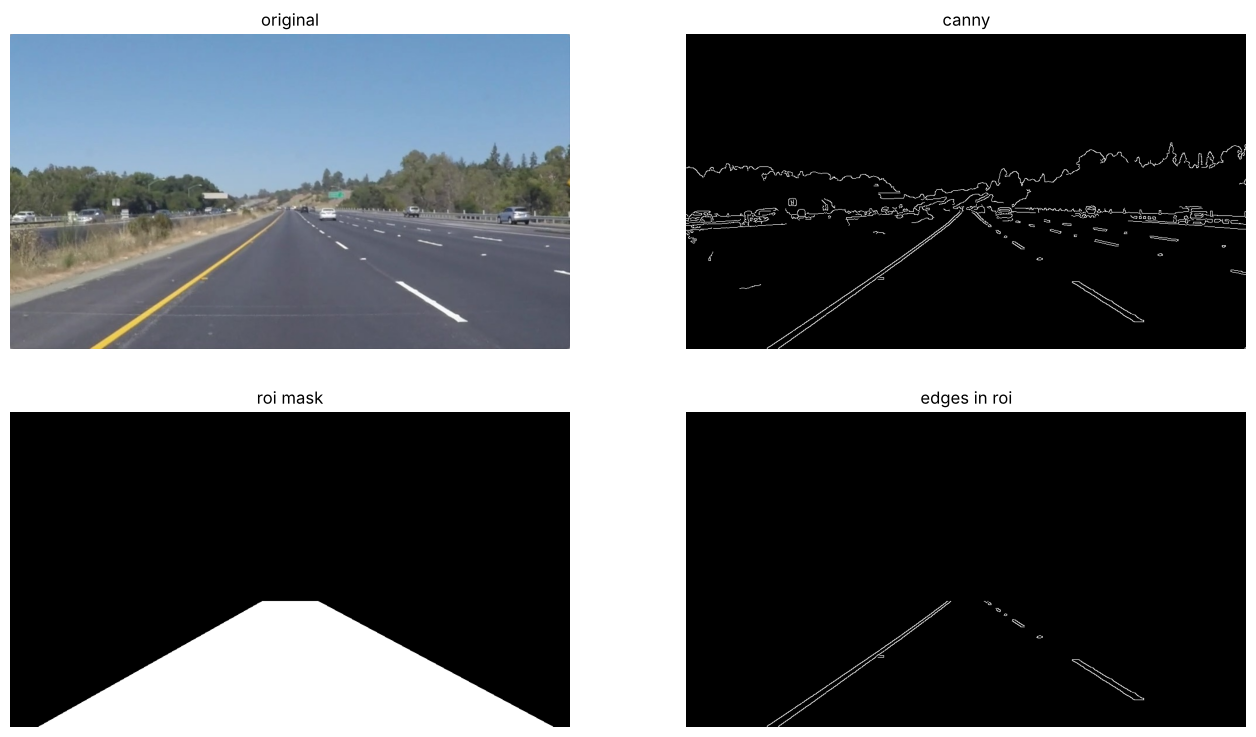

In [2]:
img = cv2.imread(files[2])
h, w = img.shape[:2]
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 50, 150)

# only the road area in front of car
roi = np.array([[(int(0.05*w), h), (int(0.45*w), int(0.6*h)), (int(0.55*w), int(0.6*h)), (int(0.97*w), h)]], np.int32)
mask = np.zeros_like(edges)
cv2.fillPoly(mask, roi, 255)
roi_edges = cv2.bitwise_and(edges, mask)

plt.figure(figsize=(16, 9))
plt.subplot(2, 2, 1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("original"); plt.axis("off")
plt.subplot(2, 2, 2); plt.imshow(edges, cmap="gray"); plt.title("canny"); plt.axis("off")
plt.subplot(2, 2, 3); plt.imshow(mask, cmap="gray"); plt.title("roi mask"); plt.axis("off")
plt.subplot(2, 2, 4); plt.imshow(roi_edges, cmap="gray"); plt.title("edges in roi"); plt.axis("off")
plt.show()

lines: 10


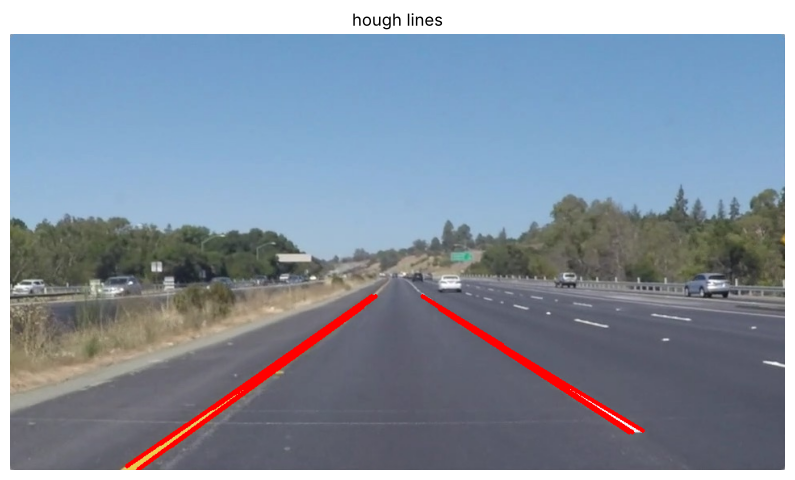

In [3]:
lines = cv2.HoughLinesP(roi_edges, 2, np.pi / 180, 40, minLineLength=30, maxLineGap=150)
lines = lines.reshape(-1, 4)
print("lines:", len(lines))

temp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
for x1, y1, x2, y2 in lines:
    cv2.line(temp, (x1, y1), (x2, y2), (255, 0, 0), 3)
plt.figure(figsize=(10, 6)); plt.imshow(temp); plt.title("hough lines"); plt.axis("off"); plt.show()

### left and right lane
negative slope = left, positive slope = right (because y goes down in images)

left: (145, 540, 436, 334)  right: (849, 540, 525, 334)


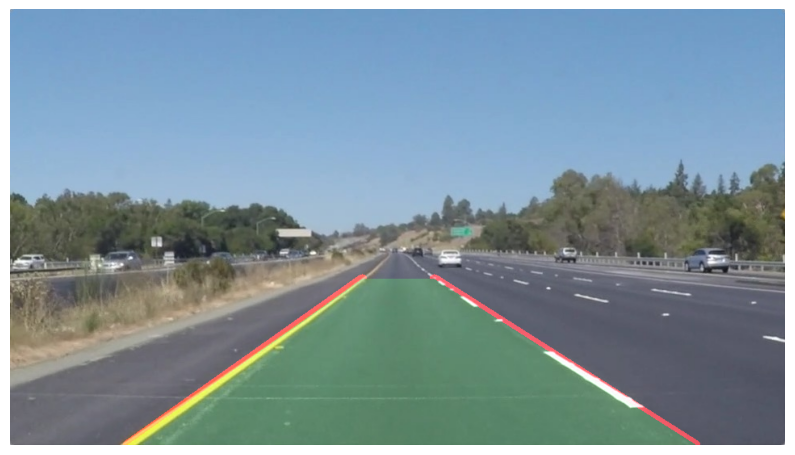

In [4]:
def average_lanes(lines, h):
    top = int(0.62 * h)
    left = []
    right = []
    for x1, y1, x2, y2 in lines:
        if x1 == x2:
            continue
        slope = (y2 - y1) / (x2 - x1)
        if slope < -0.5:
            left.append((x1, y1, x2, y2))
        elif slope > 0.5:
            right.append((x1, y1, x2, y2))
    lanes = []
    for side in [left, right]:
        if len(side) == 0:
            lanes.append(None)
            continue
        xs = []
        ys = []
        for x1, y1, x2, y2 in side:
            xs += [x1, x2]
            ys += [y1, y2]
        a, b = np.polyfit(ys, xs, 1)      # x = a*y + b
        lanes.append((int(a * h + b), h, int(a * top + b), top))
    return lanes

def draw(img, lanes):
    layer = np.zeros_like(img)
    for l in lanes:
        if l is not None:
            cv2.line(layer, (l[0], l[1]), (l[2], l[3]), (0, 0, 255), 12)
    if lanes[0] is not None and lanes[1] is not None:
        L, R = lanes
        pts = np.array([[(L[0], L[1]), (L[2], L[3]), (R[2], R[3]), (R[0], R[1])]], np.int32)
        cv2.fillPoly(layer, pts, (0, 70, 0))
    return cv2.addWeighted(img, 1, layer, 0.6, 0)

lanes = average_lanes(lines, h)
print("left:", lanes[0], " right:", lanes[1])
res = draw(img, lanes)
plt.figure(figsize=(10, 6)); plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

### all images

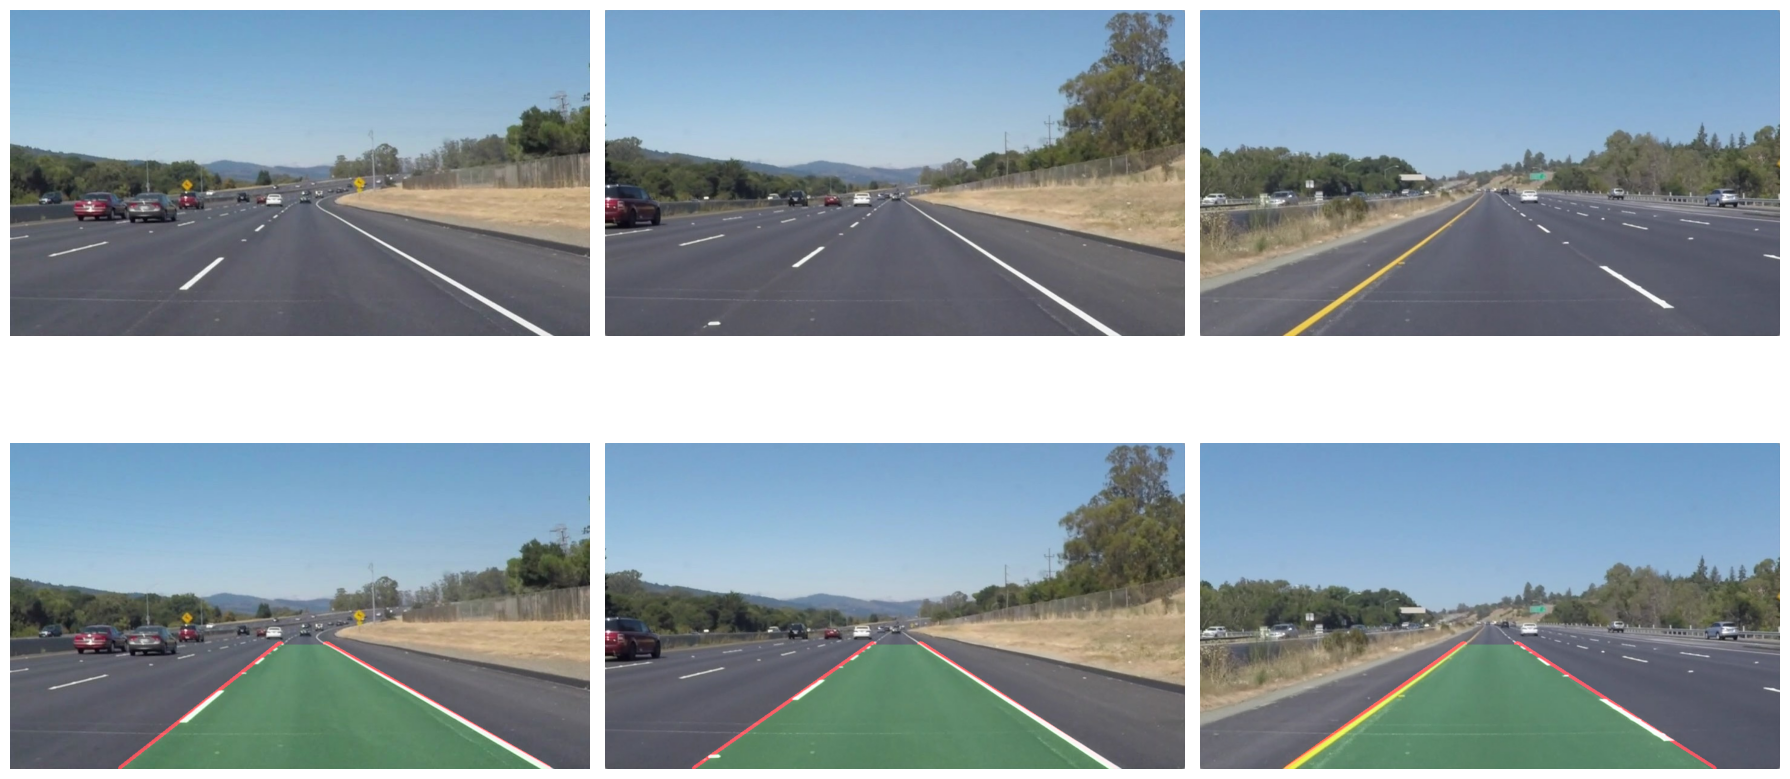

In [5]:
def lane_detect(img):
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 50, 150)
    roi = np.array([[(int(0.05*w), h), (int(0.45*w), int(0.6*h)), (int(0.55*w), int(0.6*h)), (int(0.97*w), h)]], np.int32)
    mask = np.zeros_like(edges)
    cv2.fillPoly(mask, roi, 255)
    lines = cv2.HoughLinesP(cv2.bitwise_and(edges, mask), 2, np.pi / 180, 40, minLineLength=30, maxLineGap=150)
    if lines is None:
        return img, [None, None]
    lanes = average_lanes(lines.reshape(-1, 4), h)
    return draw(img, lanes), lanes

plt.figure(figsize=(18, 10))
for i, f in enumerate(files):
    im = cv2.imread(f)
    res, lanes = lane_detect(im)
    cv2.imwrite("outputs/task6_" + f.split("/")[-1], res)
    plt.subplot(2, 3, i + 1); plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); plt.axis("off")
    plt.subplot(2, 3, i + 4); plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout()
plt.show()

### on video
also mixing with previous frame a bit so lines dont shake

frames: 221  both lanes found: 221


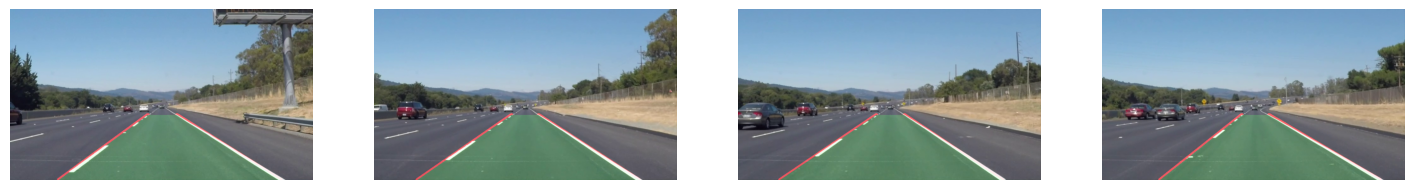

In [6]:
cap = cv2.VideoCapture("images/solidWhiteRight.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
W = int(cap.get(3))
H = int(cap.get(4))
out = cv2.VideoWriter("outputs/task6_lanes_video.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, H))

prev = [None, None]
count = 0
both = 0
frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    _, lanes = lane_detect(frame)
    new = []
    for p, l in zip(prev, lanes):
        if l is None:
            new.append(p)
        elif p is None:
            new.append(l)
        else:
            new.append(tuple(int(0.7 * a + 0.3 * b) for a, b in zip(p, l)))
    prev = new
    res = draw(frame, new)
    out.write(res)
    count += 1
    if lanes[0] is not None and lanes[1] is not None:
        both += 1
    if count in [1, 60, 120, 200]:
        frames.append(res)
cap.release()
out.release()
print("frames:", count, " both lanes found:", both)

plt.figure(figsize=(18, 4))
for i in range(len(frames)):
    plt.subplot(1, 4, i + 1); plt.imshow(cv2.cvtColor(frames[i], cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.show()